In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Laden der Rohdaten (stündliche Messwerte Nürnberg 1980–2024)
df = pd.read_csv("../03_app/data/../data/raw/data.csv")

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df.set_index("timestamp", inplace=True)
elif "datum" in df.columns and "stunde" in df.columns:
    df["timestamp"] = pd.to_datetime(df["datum"]) + pd.to_timedelta(df["stunde"], unit="h")
    df.set_index("timestamp", inplace=True)

print(f"{len(df):,} Zeilen von {df.index.min().date()} bis {df.index.max().date()}")

394,488 Zeilen von 1980-01-01 bis 2024-12-31


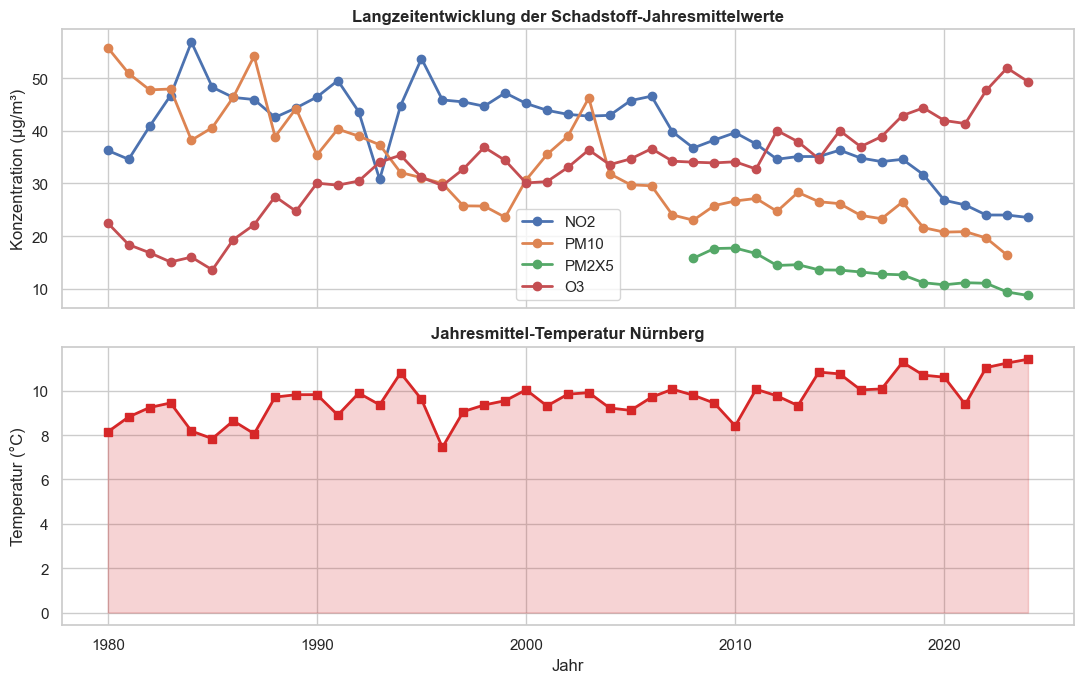

In [4]:
schadstoffe = ["no2", "pm10", "pm2x5", "o3"]

df_yearly_schad = df[schadstoffe].resample("YE").mean()
df_yearly_temp = df["temperatur"].resample("YE").mean()
df_yearly_schad.index = df_yearly_schad.index.year
df_yearly_temp.index = df_yearly_temp.index.year

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Oben: Schadstoffe
for col in schadstoffe:
    ax1.plot(df_yearly_schad.index, df_yearly_schad[col],
             marker="o", linewidth=2, label=col.upper())
ax1.set_ylabel("Konzentration (µg/m³)")
ax1.set_title("Langzeitentwicklung der Schadstoff-Jahresmittelwerte",
              fontsize=12, fontweight="bold")
ax1.legend()

# Unten: Temperatur
ax2.plot(df_yearly_temp.index, df_yearly_temp.values,
         marker="s", linewidth=2, color="tab:red")
ax2.fill_between(df_yearly_temp.index, df_yearly_temp.values,
                 alpha=0.2, color="tab:red")
ax2.set_xlabel("Jahr")
ax2.set_ylabel("Temperatur (°C)")
ax2.set_title("Jahresmittel-Temperatur Nürnberg",
              fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

C:\Users\fhasd\AppData\Local\Temp\ipykernel_10624\3949323189.py:100: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\fhasd\AppData\Local\Temp\ipykernel_10624\3949323189.py:100: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\fhasd\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\fhasd\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


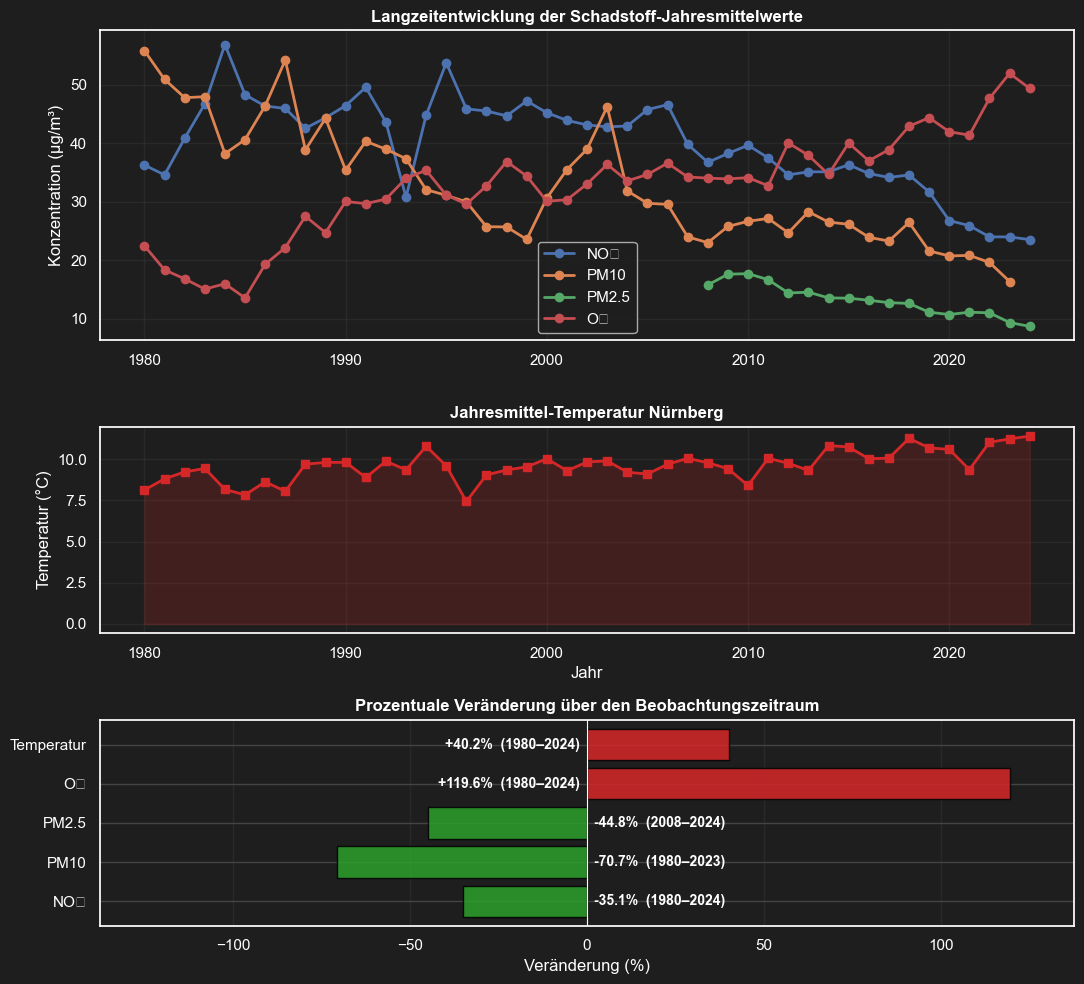

In [ ]:
schadstoffe = ["no2", "pm10", "pm2x5", "o3"]

df_yearly_schad = df[schadstoffe].resample("YE").mean()
df_yearly_temp = df["temperatur"].resample("YE").mean()
df_yearly_schad.index = df_yearly_schad.index.year
df_yearly_temp.index = df_yearly_temp.index.year

# --- Prozentuale Veränderung berechnen ---
def proz_veraenderung(serie):
    serie_clean = serie.dropna()
    start_jahr = serie_clean.index.min()
    end_jahr = serie_clean.index.max()
    start_wert = serie_clean.iloc[0]
    end_wert = serie_clean.iloc[-1]
    proz = (end_wert - start_wert) / start_wert * 100
    return proz, start_jahr, end_jahr, start_wert, end_wert

# Sprechende Achsenbeschriftungen je Spalte
label_map = {
    "no2":   r"NO$_2$",
    "pm10":  "PM10",
    "pm2x5": "PM2.5",
    "o3":    r"O$_3$",
}

# seaborn darkgrid mit angepassten Farben für dunklen Hintergrund
plt.style.use("dark_background")
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#1e1e1e",
    "figure.facecolor": "#1e1e1e",
    "grid.color": "#444444",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "axes.edgecolor": "white",
})

veraenderungen = {}
for col in schadstoffe:
    veraenderungen[label_map[col]] = proz_veraenderung(df_yearly_schad[col])
veraenderungen["Temperatur"] = proz_veraenderung(df_yearly_temp)

# --- Plot ---
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(11, 10),
    gridspec_kw={"height_ratios": [3, 2, 2]}
)

# Oben: Schadstoffe
for col in schadstoffe:
    ax1.plot(df_yearly_schad.index, df_yearly_schad[col],
             marker="o", linewidth=2, label=label_map[col])
ax1.set_ylabel("Konzentration (µg/m³)")
ax1.set_title("Langzeitentwicklung der Schadstoff-Jahresmittelwerte",
              fontsize=12, fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Mitte: Temperatur
ax2.plot(df_yearly_temp.index, df_yearly_temp.values,
         marker="s", linewidth=2, color="tab:red")
ax2.fill_between(df_yearly_temp.index, df_yearly_temp.values,
                 alpha=0.2, color="tab:red")
ax2.set_xlabel("Jahr")
ax2.set_ylabel("Temperatur (°C)")
ax2.set_title("Jahresmittel-Temperatur Nürnberg",
              fontsize=12, fontweight="bold")
ax2.grid(True, alpha=0.3)

# Unten: Prozentuale Veränderung
labels = list(veraenderungen.keys())
werte = [v[0] for v in veraenderungen.values()]
zeitraeume = [f"{v[1]}–{v[2]}" for v in veraenderungen.values()]

farben = ["#2ca02c" if w < 0 else "#d62728" for w in werte]
balken = ax3.barh(labels, werte, color=farben, alpha=0.85, edgecolor="black")
ax3.axvline(0, color="white", linewidth=0.8)
ax3.set_xlabel("Veränderung (%)")
ax3.set_title("Prozentuale Veränderung über den Beobachtungszeitraum",
              fontsize=12, fontweight="bold")
ax3.grid(True, alpha=0.3, axis="x")

# Beschriftung INNERHALB der Balken (nahe der Nulllinie)
for balken_obj, wert, zeitraum in zip(balken, werte, zeitraeume):
    breite = balken_obj.get_width()
    y_pos = balken_obj.get_y() + balken_obj.get_height() / 2
    # Bei negativem Balken: Text knapp rechts der Nulllinie ausrichten
    # Bei positivem Balken: Text knapp links der Nulllinie ausrichten
    if breite < 0:
        x_pos = 2
        ha = "left"
    else:
        x_pos = -2
        ha = "right"
    ax3.text(x_pos, y_pos,
             f"{wert:+.1f}%  ({zeitraum})",
             va="center", ha=ha, fontsize=10, fontweight="bold",
             color="white")

# X-Achse symmetrisch und mit Puffer
max_abs = max(abs(min(werte)), abs(max(werte)))
ax3.set_xlim(-max_abs * 1.15, max_abs * 1.15)

plt.tight_layout()
plt.show()


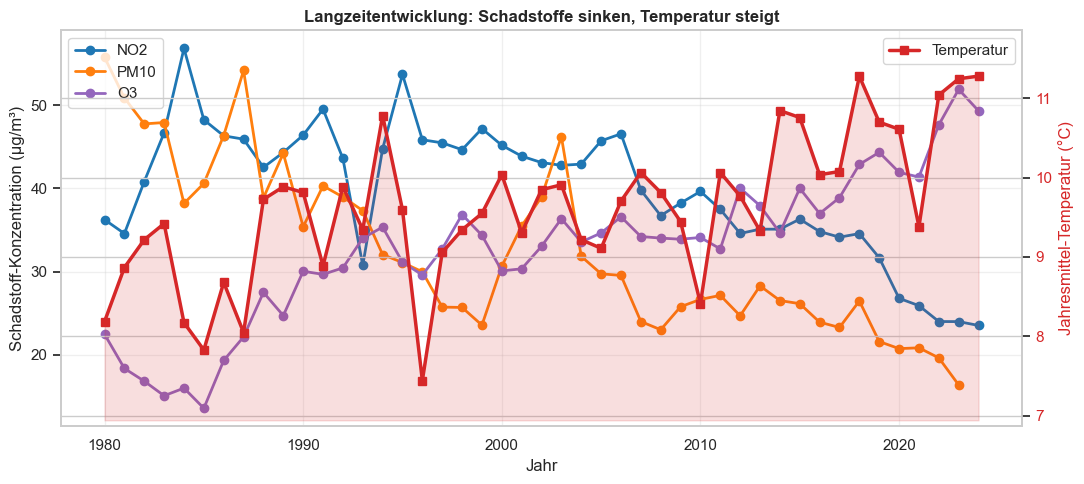

In [5]:
schadstoffe = ["no2", "pm10", "o3"]
temp_col = "temperatur_2m"

df_yearly_schad = df[schadstoffe].resample("YE").mean()
df_yearly_temp = df[temp_col].resample("YE").mean()
df_yearly_schad.index = df_yearly_schad.index.year
df_yearly_temp.index = df_yearly_temp.index.year

fig, ax1 = plt.subplots(figsize=(11, 5))

# Linke Achse: Schadstoffe
farben_schad = {"no2": "tab:blue", "pm10": "tab:orange", "o3": "tab:purple"}
for col in schadstoffe:
    ax1.plot(df_yearly_schad.index, df_yearly_schad[col],
             marker="o", linewidth=2, label=col.upper(),
             color=farben_schad[col])
ax1.set_xlabel("Jahr")
ax1.set_ylabel("Schadstoff-Konzentration (µg/m³)")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# Rechte Achse: Temperatur - hier kommt der Trick
ax2 = ax1.twinx()
ax2.plot(df_yearly_temp.index, df_yearly_temp.values,
         marker="s", linewidth=2.5, color="tab:red",
         linestyle="-", label="Temperatur", zorder=5)
ax2.fill_between(df_yearly_temp.index, df_yearly_temp.values,
                 df_yearly_temp.min() - 0.5,
                 alpha=0.15, color="tab:red")
ax2.set_ylabel("Jahresmittel-Temperatur (°C)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Y-Achse Temperatur ENG zuschneiden -> macht den Anstieg dramatisch sichtbar
temp_min = df_yearly_temp.min()
temp_max = df_yearly_temp.max()
puffer = (temp_max - temp_min) * 0.15
ax2.set_ylim(temp_min - puffer, temp_max + puffer)

ax2.legend(loc="upper right")

plt.title("Langzeitentwicklung: Schadstoffe sinken, Temperatur steigt",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

Referenz-Temperatur 1980-1989: 8.80 °C
Anomalie 2024 vs. Referenz: +2.47 °C


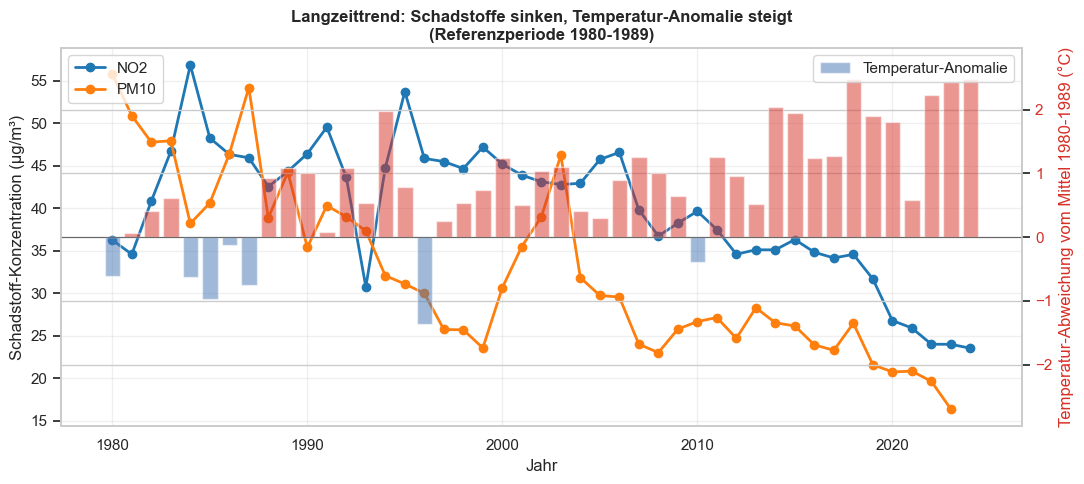

In [7]:
schadstoffe = ["no2", "pm10"]
temp_col = "temperatur_2m"

# Jahresmittel berechnen
df_yearly_schad = df[schadstoffe].resample("YE").mean()
df_yearly_temp = df[temp_col].resample("YE").mean()
df_yearly_schad.index = df_yearly_schad.index.year
df_yearly_temp.index = df_yearly_temp.index.year

# Temperatur-Anomalie: Abweichung vom Mittel der Referenzperiode 1980-1989
# Referenzperiode 1980–1989 als klimatologische Basis (vorindustrielle Nahzeit)
basis_periode = df_yearly_temp.loc[1980:1989].mean()
df_temp_anomalie = df_yearly_temp - basis_periode

print(f"Referenz-Temperatur 1980-1989: {basis_periode:.2f} °C")
print(f"Anomalie 2024 vs. Referenz: {df_temp_anomalie.iloc[-1]:+.2f} °C")

# Plot
fig, ax1 = plt.subplots(figsize=(11, 5))

# Linke Achse: Schadstoffe
farben_schad = {"no2": "tab:blue", "pm10": "tab:orange", "o3": "tab:purple"}
for col in schadstoffe:
    ax1.plot(df_yearly_schad.index, df_yearly_schad[col],
             marker="o", linewidth=2, label=col.upper(),
             color=farben_schad[col])
ax1.set_xlabel("Jahr")
ax1.set_ylabel("Schadstoff-Konzentration (µg/m³)")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# Rechte Achse: Temperatur-Anomalie
ax2 = ax1.twinx()

# Balken statt Linie - macht Anomalien sehr deutlich sichtbar
farben_temp = ["#d73027" if v > 0 else "#4575b4" for v in df_temp_anomalie.values]
ax2.bar(df_temp_anomalie.index, df_temp_anomalie.values,
        color=farben_temp, alpha=0.5, width=0.8,
        label="Temperatur-Anomalie", zorder=1)

# Nulllinie der Referenzperiode hervorheben
ax2.axhline(0, color="black", linewidth=0.8, linestyle="-", alpha=0.5)

ax2.set_ylabel("Temperatur-Abweichung vom Mittel 1980-1989 (°C)",
               color="#d73027")
ax2.tick_params(axis="y", labelcolor="#d73027")
ax2.legend(loc="upper right")

# Symmetrische y-Achse für Anomalie (negativ und positiv gleich sichtbar)
max_abs = max(abs(df_temp_anomalie.min()), abs(df_temp_anomalie.max()))
ax2.set_ylim(-max_abs * 1.2, max_abs * 1.2)

plt.title("Langzeittrend: Schadstoffe sinken, Temperatur-Anomalie steigt\n(Referenzperiode 1980-1989)",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
st.info("""
💡 **Lesehilfe zum Chart:**  
Die **Linien** zeigen die Jahresmittel der Schadstoffe in µg/m³ (linke Achse) — 
der Trend ist klar rückläufig, ein Erfolg der Luftreinhaltungspolitik.  
Die **Balken** zeigen, wie stark das Jahresmittel der Temperatur 
vom Durchschnitt der 1980er Jahre abweicht (rechte Achse). 
🔵 Blaue Balken bedeuten kühler, 🔴 rote Balken wärmer als die Referenzperiode. 
Während die Schadstoffe sinken, häufen sich rote Balken — ein direkter Indikator 
für den fortschreitenden Klimawandel.
""")